# Analyze and visualize sentiment patterns in social media data to understand public opinions and attitudes towards specific topics or brands.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(
    "datasets/twitter_training.csv",
    header=None,
    names=["tweet_id", "topic", "sentiment", "text"],
    encoding="utf-8",
    on_bad_lines="skip"
)
 
print("Shape:", df.shape)
print("\nSentiment counts:\n", df["sentiment"].value_counts())
print("\nTop 10 topics:\n", df["topic"].value_counts().head(10))

Shape: (74682, 4)

Sentiment counts:
 sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

Top 10 topics:
 topic
Microsoft                    2400
MaddenNFL                    2400
TomClancysRainbowSix         2400
LeagueOfLegends              2394
CallOfDuty                   2394
Verizon                      2382
CallOfDutyBlackopsColdWar    2376
ApexLegends                  2376
Facebook                     2370
WorldOfCraft                 2364
Name: count, dtype: int64


In [3]:
df.dropna(subset=["sentiment", "topic"], inplace=True)
df["sentiment"] = df["sentiment"].str.strip()
df["topic"]     = df["topic"].str.strip()

In [4]:
COLORS = {
    "Positive":   "#3b6d11",
    "Negative":   "#a32d2d",
    "Neutral":    "#888780",
    "Irrelevant": "#b5d4f4",
}

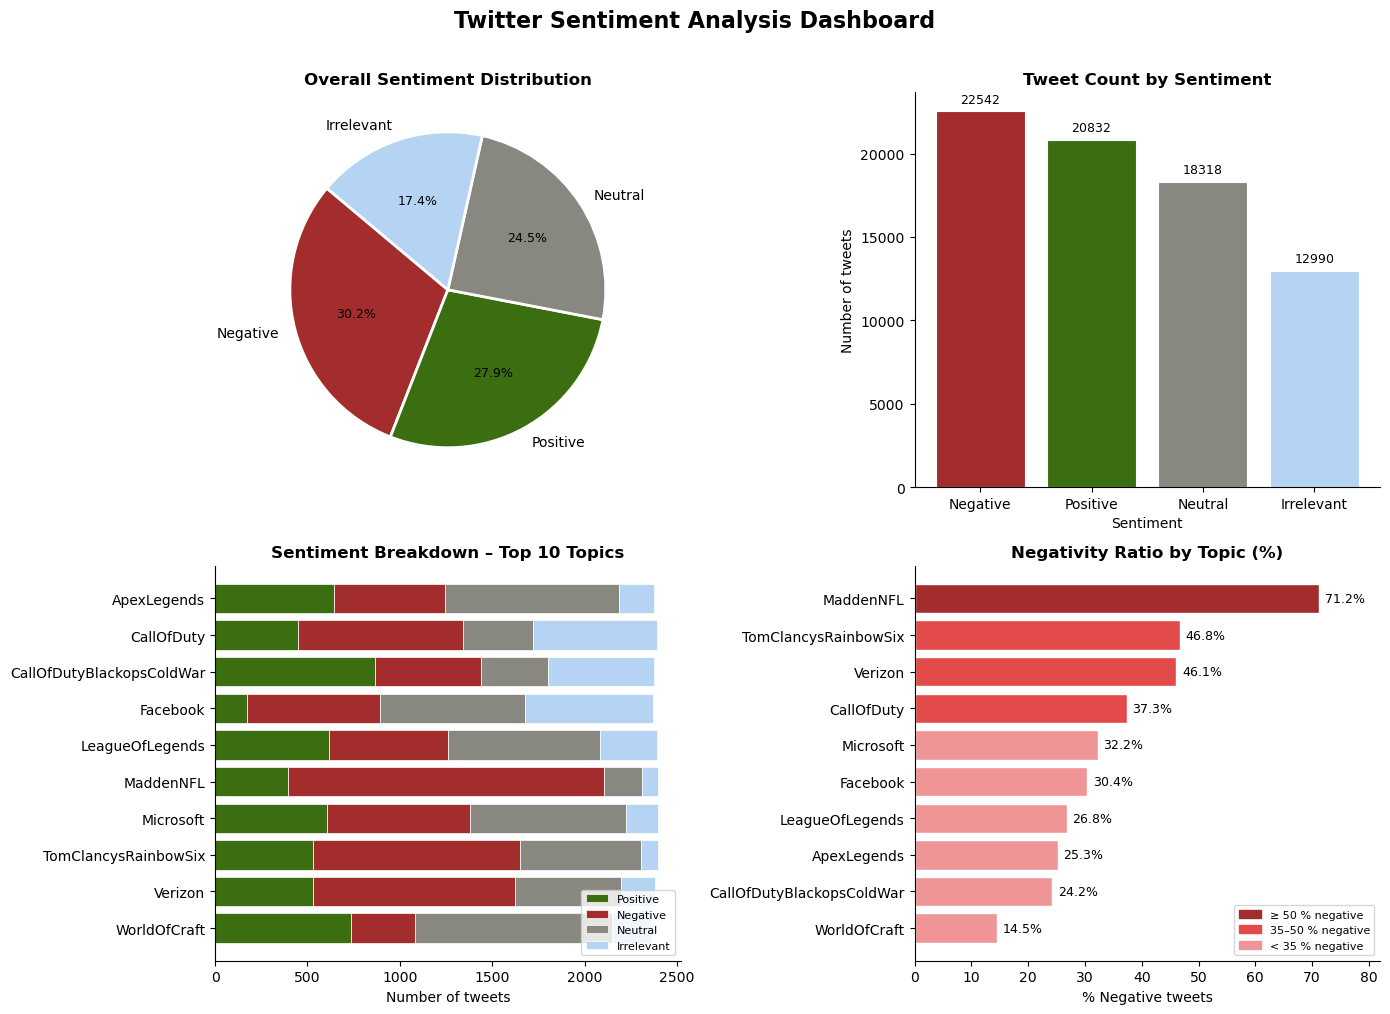


Plot saved → twitter_sentiment_dashboard.png


In [10]:
sentiment_counts = df["sentiment"].value_counts()
sentiment_pct    = sentiment_counts / sentiment_counts.sum() * 100
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Twitter Sentiment Analysis Dashboard", fontsize=16, fontweight="bold", y=1.01)
 
#piechart

ax = axes[0, 0]
wedge_colors = [COLORS.get(s, "#cccccc") for s in sentiment_counts.index]
wedges, texts, autotexts = ax.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    colors=wedge_colors,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=2),
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title("Overall Sentiment Distribution", fontweight="bold")
 
#barchart

ax = axes[0, 1]
bars = ax.bar(
    sentiment_counts.index,
    sentiment_counts.values,
    color=wedge_colors,
    edgecolor="white",
    linewidth=0.8,
)
ax.bar_label(bars, fmt="%d", padding=4, fontsize=9)
ax.set_title("Tweet Count by Sentiment", fontweight="bold")
ax.set_ylabel("Number of tweets")
ax.set_xlabel("Sentiment")
ax.spines[["top", "right"]].set_visible(False)

top10 = df["topic"].value_counts().head(10).index.tolist()
topic_df = (
    df[df["topic"].isin(top10)]
    .groupby(["topic", "sentiment"])
    .size()
    .unstack(fill_value=0)
)
# keep consistent column order
col_order = [c for c in ["Positive", "Negative", "Neutral", "Irrelevant"] if c in topic_df.columns]
topic_df  = topic_df[col_order]
 
ax = axes[1, 0]
bottom = pd.Series([0] * len(topic_df), index=topic_df.index)
for sentiment in col_order:
    ax.barh(
        topic_df.index,
        topic_df[sentiment],
        left=bottom,
        color=COLORS.get(sentiment, "#cccccc"),
        label=sentiment,
        edgecolor="white",
        linewidth=0.5,
    )
    bottom = bottom + topic_df[sentiment]
 
ax.set_title("Sentiment Breakdown – Top 10 Topics", fontweight="bold")
ax.set_xlabel("Number of tweets")
ax.legend(loc="lower right", fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
ax.invert_yaxis()

topic_totals   = topic_df.sum(axis=1)
neg_ratio      = (topic_df.get("Negative", 0) / topic_totals * 100).sort_values()
 
ax = axes[1, 1]
bar_colors = ["#a32d2d" if v >= 50 else "#e24b4a" if v >= 35 else "#f09595"
              for v in neg_ratio.values]
bars = ax.barh(neg_ratio.index, neg_ratio.values, color=bar_colors, edgecolor="white")
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=9)
ax.set_title("Negativity Ratio by Topic (%)", fontweight="bold")
ax.set_xlabel("% Negative tweets")
ax.set_xlim(0, neg_ratio.max() * 1.15)
ax.spines[["top", "right"]].set_visible(False)
 
# legend
patches = [
    mpatches.Patch(color="#a32d2d", label="≥ 50 % negative"),
    mpatches.Patch(color="#e24b4a", label="35–50 % negative"),
    mpatches.Patch(color="#f09595", label="< 35 % negative"),
]
ax.legend(handles=patches, fontsize=8, loc="lower right")
 
plt.tight_layout()
plt.savefig("twitter_sentiment_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved → twitter_sentiment_dashboard.png")

In [11]:
print("\n── Summary ──────────────────────────────────────────────")
print(f"Total tweets analysed : {len(df):,}")
for s, pct in sentiment_pct.items():
    print(f"  {s:<12}: {sentiment_counts[s]:>6,}  ({pct:.1f} %)")
 
print("\nMost negative topics:")
neg_ratio_all = (
    df[df["sentiment"] == "Negative"]
    .groupby("topic").size() /
    df.groupby("topic").size() * 100
).dropna().sort_values(ascending=False).head(5)
for t, v in neg_ratio_all.items():
    print(f"  {t:<35} {v:.1f} %")
 
print("\nMost positive topics:")
pos_ratio_all = (
    df[df["sentiment"] == "Positive"]
    .groupby("topic").size() /
    df.groupby("topic").size() * 100
).dropna().sort_values(ascending=False).head(5)
for t, v in pos_ratio_all.items():
    print(f"  {t:<35} {v:.1f} %")


── Summary ──────────────────────────────────────────────
Total tweets analysed : 74,682
  Negative    : 22,542  (30.2 %)
  Positive    : 20,832  (27.9 %)
  Neutral     : 18,318  (24.5 %)
  Irrelevant  : 12,990  (17.4 %)

Most negative topics:
  MaddenNFL                           71.2 %
  NBA2K                               62.8 %
  FIFA                                50.3 %
  TomClancysRainbowSix                46.8 %
  Verizon                             46.1 %

Most positive topics:
  AssassinsCreed                      64.4 %
  Borderlands                         44.6 %
  Cyberpunk2077                       41.9 %
  RedDeadRedemption(RDR)              41.1 %
  PlayStation5(PS5)                   40.8 %
